# llm-tokens-atlas — calibration analysis

Open notebook for the paper *On the Calibration of Offline LLM Tokenizers: A 5-Provider Empirical Study*. Every figure and table in the paper is regenerated from this notebook.

All computations and plotting routines live in `analysis/atlas_analysis.py`; this notebook is a thin orchestrator so the logic stays diffable in git and importable from tests.

Inputs: `data/processed/atlas.parquet` (built by `make build`).

Outputs: `analysis/figures/*.png|*.pdf`, `analysis/tables/*.md`, `analysis/results.json`.

In [1]:
import sys  # noqa: E402
from pathlib import Path  # noqa: E402

# Make analysis/ importable when the notebook is opened directly.
NB_DIR = Path.cwd()
ANALYSIS_DIR = (
    NB_DIR if (NB_DIR / 'atlas_analysis.py').exists() else NB_DIR.parent
)
REPO_ROOT = ANALYSIS_DIR.parent
sys.path.insert(0, str(ANALYSIS_DIR))

import atlas_analysis as aa  # noqa: E402
import pandas as pd  # noqa: E402,F401
from IPython.display import Image  # noqa: E402

aa.set_publication_style()

PARQUET_PATH = REPO_ROOT / 'data' / 'processed' / 'atlas.parquet'
FIGURES_DIR = REPO_ROOT / 'analysis' / 'figures'
TABLES_DIR = REPO_ROOT / 'analysis' / 'tables'
RESULTS_PATH = REPO_ROOT / 'analysis' / 'results.json'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
# Redact absolute paths from output to keep the notebook portable.
print('repo root:', REPO_ROOT.name)
print('parquet path:', PARQUET_PATH.relative_to(REPO_ROOT), 'exists:', PARQUET_PATH.exists())

repo root: llm-tokens-atlas
parquet path: data/processed/atlas.parquet exists: True


## 1. Load + sanity

Load the joined parquet and confirm the schema is as expected. We flag any rows with `delta_pct == NaN` (the edge case is `empirical_count == 0`, which is unusual but legal — short prompts in extreme tokenizers can collapse to 0).

In [2]:
df = aa.load_atlas(PARQUET_PATH)
print('rows:', len(df))
print('schema:')
print(df.dtypes)
df.head(3)

rows: 7485
schema:
prompt_id                 str
source                    str
text                      str
text_len_chars          int64
text_len_words          int64
language                  str
domain               category
collected_at              str
provider             category
format               category
model                     str
offline_count           int64
tokenizer_version         str
offline_ts                str
empirical_count         int64
is_oracle                bool
empirical_source          str
endpoint                  str
empirical_ts              str
delta                   int64
delta_pct             float64
abs_delta               int64
direction              string
dtype: object


,prompt_id,source,text,text_len_chars,text_len_words,language,domain,collected_at,provider,format,...,offline_ts,empirical_count,is_oracle,empirical_source,endpoint,empirical_ts,delta,delta_pct,abs_delta,direction
0,2dbc2134-c30f-446e-8026-695ff8cda88b,humaneval,"def correct_bracketing(brackets: str):\n """"...",345,36,code,code,2026-05-11T00:32:32Z,anthropic,plain,...,2026-05-11T01:06:36Z,146,True,api,anthropic.messages.count_tokens (sdk anthropic...,2026-05-11T01:46:25Z,63,43.150685,63,underestimate
1,2dbc2134-c30f-446e-8026-695ff8cda88b,humaneval,"def correct_bracketing(brackets: str):\n """"...",345,36,code,code,2026-05-11T00:32:32Z,openai,plain,...,2026-05-11T01:06:36Z,85,True,tiktoken,tiktoken==0.12.0 encoding=o200k_base model=gpt-4o,2026-05-11T01:13:54Z,0,0.000000,0,exact
2,2dbc2134-c30f-446e-8026-695ff8cda88b,humaneval,"def correct_bracketing(brackets: str):\n """"...",345,36,code,code,2026-05-11T00:32:32Z,mistral,plain,...,2026-05-11T01:06:36Z,106,True,sdk,mistral-common==1.11.2 tokenizer=SentencePiece...,2026-05-11T01:13:54Z,-1,-0.943396,1,overestimate


In [3]:
report = aa.sanity_report(df)
print('n_rows                ', report.n_rows)
print('n_prompts             ', report.n_prompts)
print('providers (present)   ', report.providers)
print('formats (present)     ', report.formats)
print('domains (present)     ', report.domains)
print('n_nan_delta_pct       ', report.n_nan_delta_pct)
print('n_zero_empirical      ', report.n_zero_empirical)

n_rows                 7485
n_prompts              499
providers (present)    ['openai', 'anthropic', 'mistral']
formats (present)      ['plain', 'markdown', 'json', 'xml', 'yaml']
domains (present)      ['code', 'prose', 'chat']
n_nan_delta_pct        0
n_zero_empirical       0


In [4]:
# Summary statistics across the entire frame.
df[['offline_count', 'empirical_count', 'delta', 'delta_pct']].describe()

,offline_count,empirical_count,delta,delta_pct
count,7485.000000,7485.000000,7485.000000,7485.000000
mean,790.338277,956.818303,166.480027,15.657239
std,2279.966670,2766.532758,771.379840,19.938337
min,1.000000,1.000000,-126.000000,-100.000000
25%,48.000000,61.000000,0.000000,0.000000
50%,110.000000,135.000000,4.000000,4.823151
75%,395.000000,492.000000,52.000000,36.842105
max,36897.000000,45538.000000,18514.000000,92.307692


**Note on missing providers.** The atlas measures five providers, but rows for Anthropic / Google / Cohere only exist when the corresponding `ANTHROPIC_API_KEY` / `GOOGLE_API_KEY` / `COHERE_API_KEY` was set during `make empirical`. OpenAI and Mistral are always present because their tokenizers ship as Python libraries (tiktoken, mistral-common). Providers absent from the parquet are silently dropped by every routine below — `n` per provider in the tables shows which ran.

## 2. Per-provider calibration distribution

Violin plot of `delta_pct = (empirical - offline) / empirical * 100` per provider, accompanied by a summary table with median, p25, p75, and p95.  For Anthropic specifically, we expect to see the cl100k_base / `claude-opus-4-7` underestimate from the tokenometer foundation work, which two 2026 blog posts have informally measured at +40 to +47%. The violin shape is the paper's headline figure.

In [5]:
stats = aa.per_provider_stats(df)
stats

,provider,n,mean,median,p25,p75,p95
0,openai,2495,3.013315,0.000000,0.000000,5.132454,12.500000
1,anthropic,2495,42.106359,41.290691,36.805223,46.707525,58.561817
2,mistral,2495,1.852042,-0.059418,-0.990099,4.651163,11.764706


saved analysis/figures/fig01_violin_delta_per_provider.png


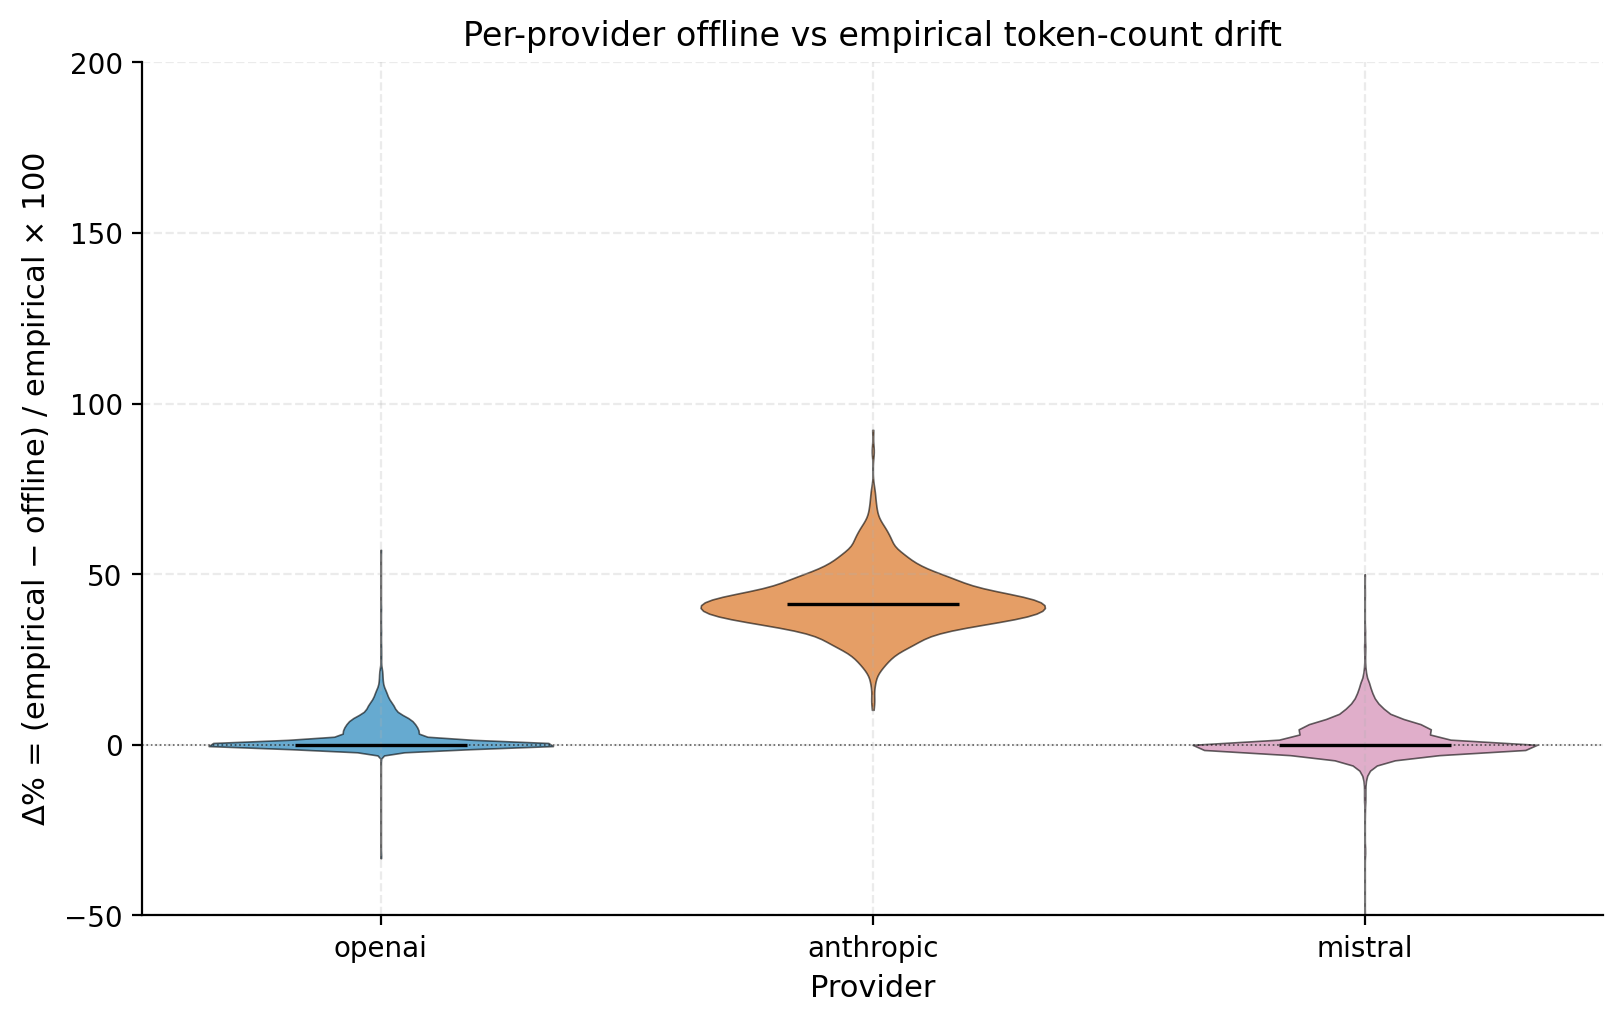

In [6]:
fig01 = aa.plot_violin_delta(
    df, FIGURES_DIR / 'fig01_violin_delta_per_provider'
)
print('saved', fig01.relative_to(REPO_ROOT))
Image(filename=str(fig01))

## 3. Per-format breakdown — load-bearing

Prior art (the 2026 blog posts, AgentOps `tokencost`) reports per-provider drift but **does not break drift down by serialization format**. This is the centerpiece novelty of the paper per the scope adjustment: a heatmap of median `delta_pct` over `format × provider`.

In [7]:
fmt_pivot = aa.per_provider_format_median(df)
fmt_pivot

provider,openai,anthropic,mistral
format,,,
plain,0.000000,38.811881,-0.840336
markdown,0.000000,39.414802,-0.735294
json,6.451613,43.987342,5.128205
xml,0.000000,40.849858,-0.636943
yaml,5.398183,41.958042,5.244507


saved analysis/figures/fig02_heatmap_format_x_provider.png


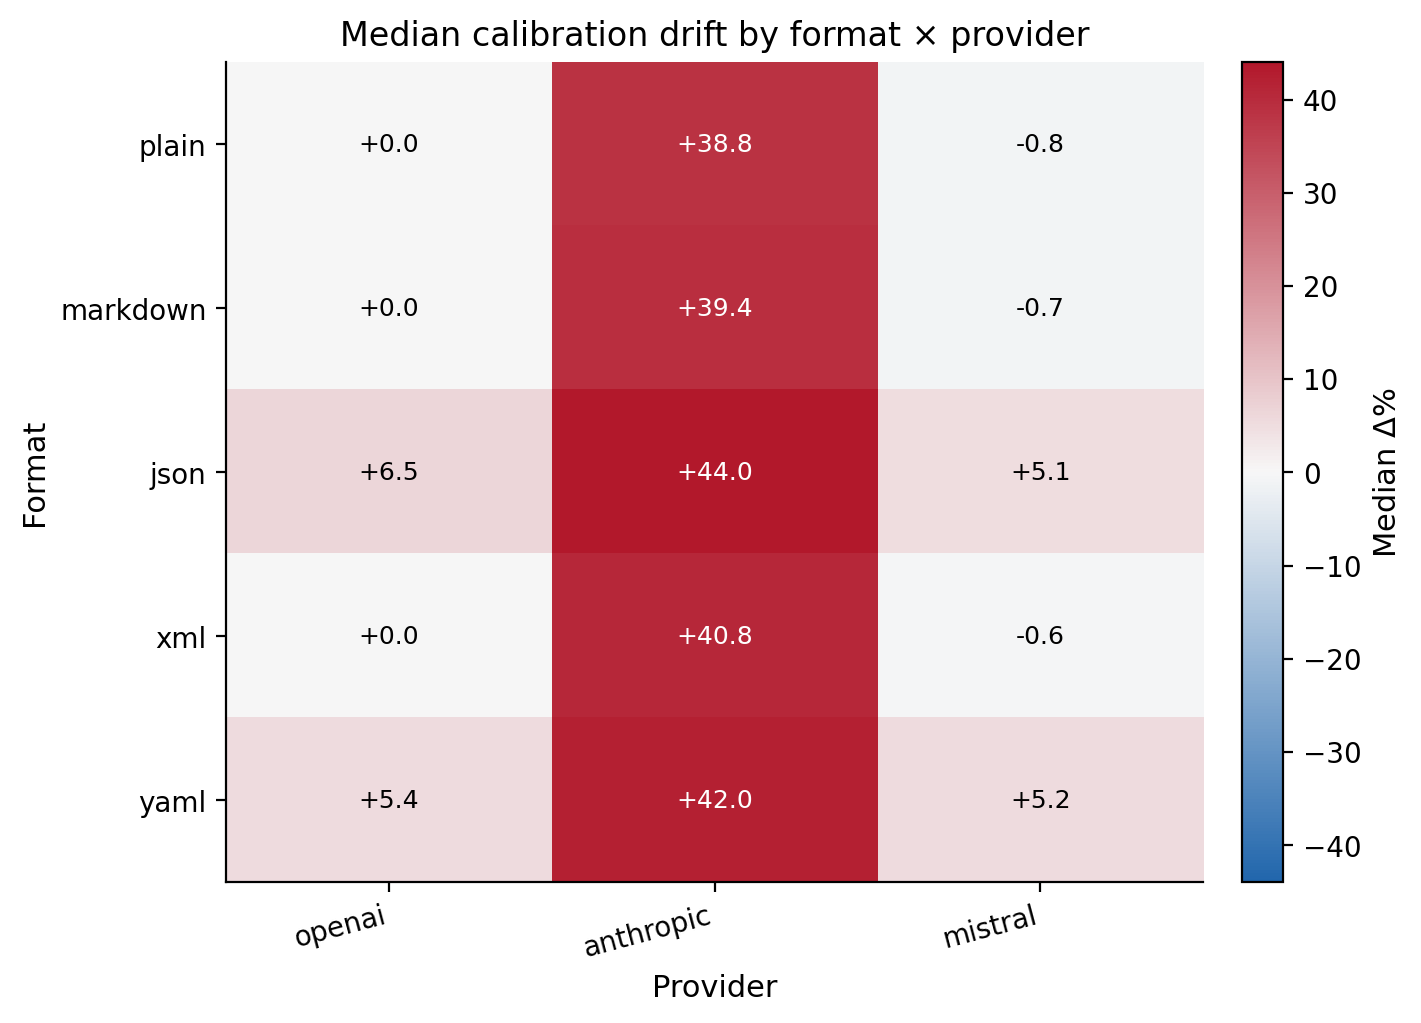

In [8]:
fig02 = aa.plot_format_heatmap(
    df, FIGURES_DIR / 'fig02_heatmap_format_x_provider'
)
print('saved', fig02.relative_to(REPO_ROOT))
Image(filename=str(fig02))

## 4. Domain effect

We tagged each prompt with a domain — `code`, `prose`, `chat`, `structured`, `multilingual`, `other`. The grouped bar chart shows how mean `delta_pct` varies by domain × provider, with SEM error bars for each cell. Practitioners can read this as: *"if my prompt is `code`, this is how much more or fewer tokens it will cost than my offline tokenizer claims."*

In [9]:
aa.per_domain_stats(df)

,domain,n,mean,std,median
0,code,2730,14.458045,17.077125,5.658260
1,prose,1770,15.756047,20.481542,3.755951
2,chat,2985,16.695399,21.891697,5.000000


saved analysis/figures/fig03_domain_effect.png


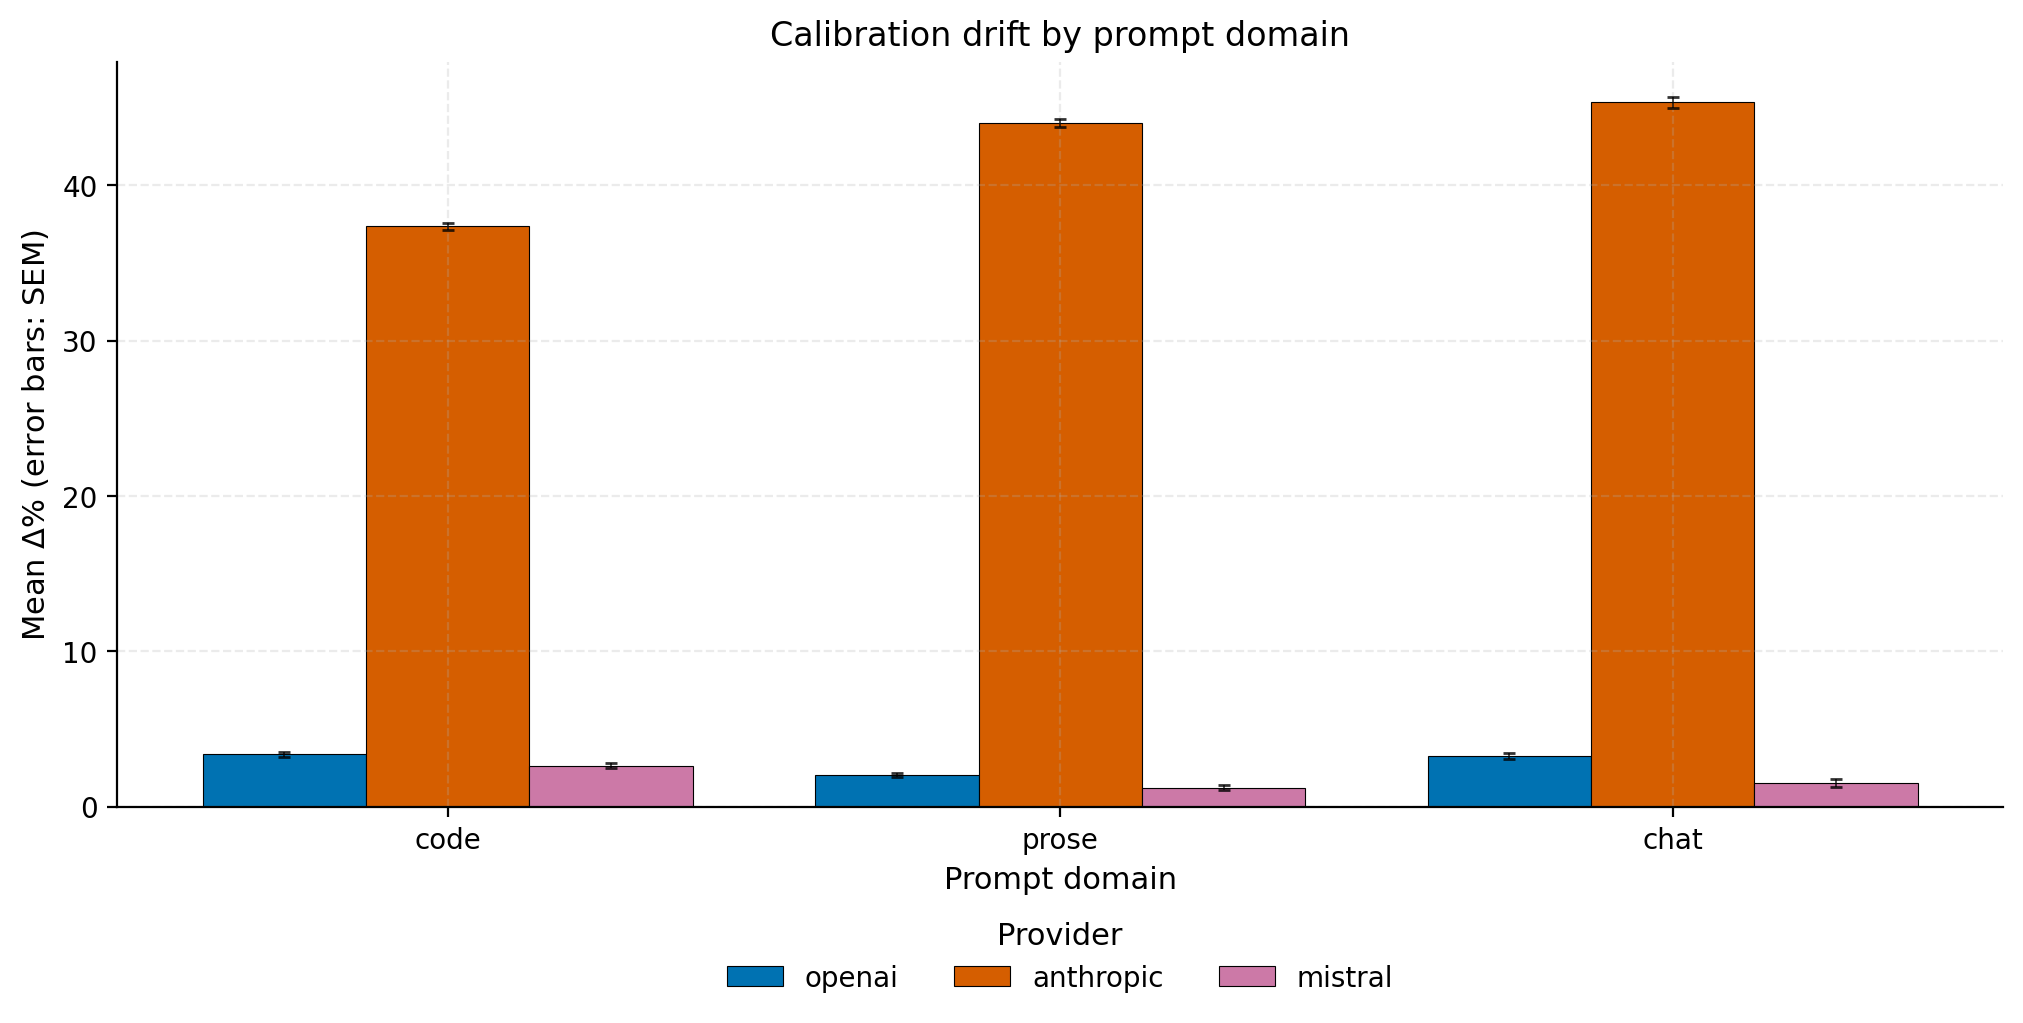

In [10]:
fig03 = aa.plot_domain_effect(
    df, FIGURES_DIR / 'fig03_domain_effect'
)
print('saved', fig03.relative_to(REPO_ROOT))
Image(filename=str(fig03))

## 5. Direction of bias

How often does the offline tokenizer underestimate, exactly match, or overestimate the empirical count? A stacked horizontal bar gives one row per provider with the three shares.

In [11]:
aa.per_provider_bias_direction(df).mul(100).round(1).rename(columns=lambda c: c + ' %')

direction,underestimate %,exact %,overestimate %
provider,,,
openai,42.4,57.1,0.5
anthropic,100.0,0.0,0.0
mistral,42.1,0.1,57.8


saved analysis/figures/fig04_bias_direction.png


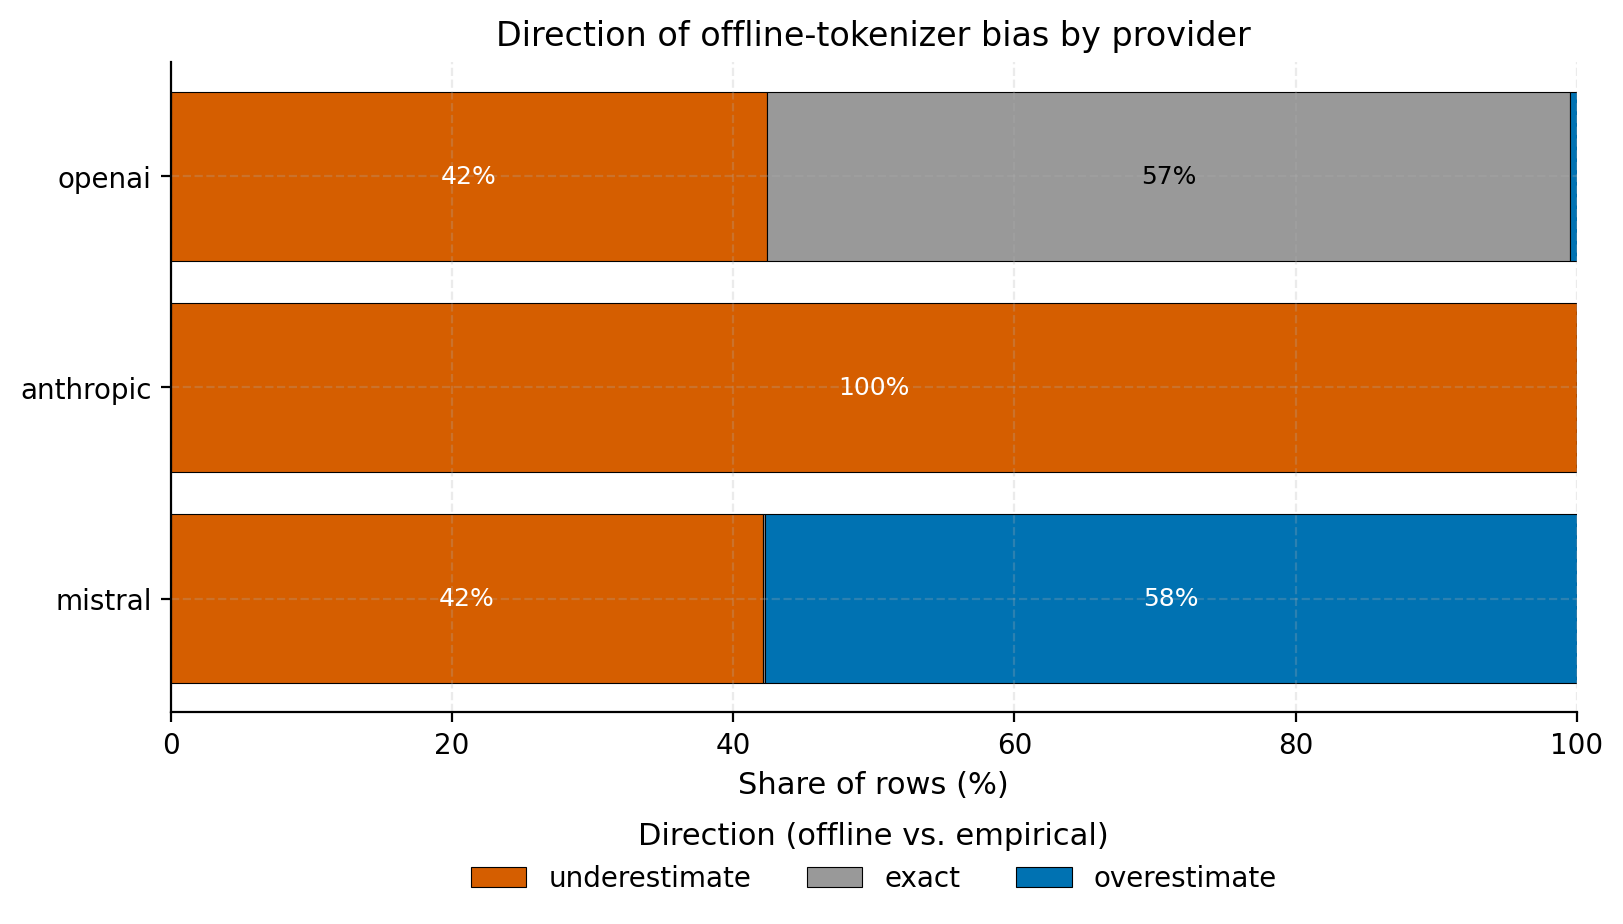

In [12]:
fig04 = aa.plot_bias_direction(
    df, FIGURES_DIR / 'fig04_bias_direction'
)
print('saved', fig04.relative_to(REPO_ROOT))
Image(filename=str(fig04))

## 6. Calibration model — per-provider correction factors

We fit a simple linear regression `empirical = slope * offline + intercept` per provider and report slope, intercept, and R². The slope is the per-provider correction factor a practitioner could apply to their existing offline-tokenizer pipeline to get a first-order calibrated estimate of true token cost. R² near 1.0 indicates the residuals are small relative to the signal — the offline tokenizer is wrong, but consistently wrong.

In [13]:
fits = aa.per_provider_calibration_fits(df)
pd.DataFrame([{
    'provider': f.provider,
    'n': f.n,
    'slope': round(f.slope, 4),
    'intercept': round(f.intercept, 2),
    'R^2': round(f.r_squared, 4),
} for f in fits])

,provider,n,slope,intercept,R^2
0,openai,2495,1.0240,1.75,0.9986
1,anthropic,2495,1.6107,18.20,0.9956
2,mistral,2495,1.0162,2.49,0.9993


saved analysis/figures/fig05_calibration_regression.png


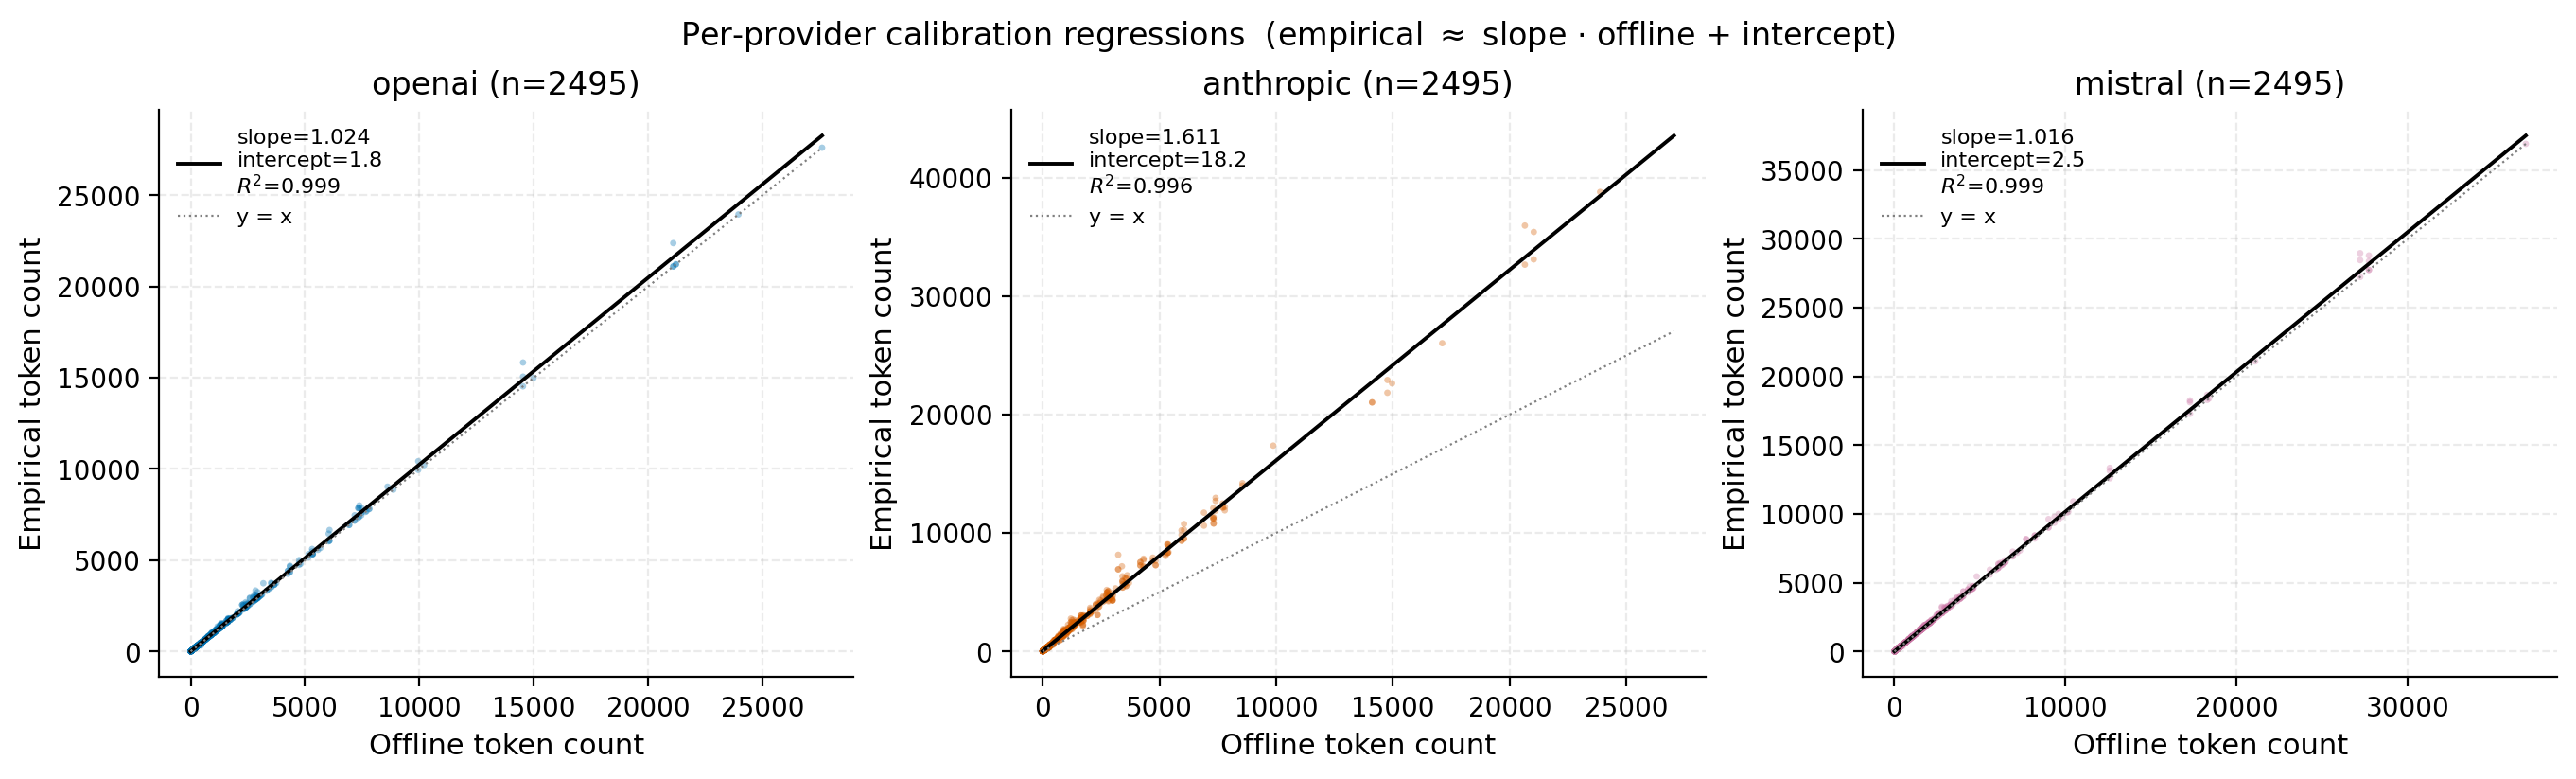

In [14]:
fig05 = aa.plot_calibration_regression(
    df, FIGURES_DIR / 'fig05_calibration_regression'
)
print('saved', fig05.relative_to(REPO_ROOT))
Image(filename=str(fig05))

## 7. Persist tables + machine-readable results

All numerical findings are written to `analysis/results.json` for the paper-results agent to inline. Markdown tables for paper inlining are written to `analysis/tables/`.

In [15]:
(TABLES_DIR / 'tab01_summary_stats.md').write_text(
    aa.render_provider_stats_md(df), encoding='utf-8'
)
(TABLES_DIR / 'tab02_format_heatmap.md').write_text(
    aa.render_format_heatmap_md(df), encoding='utf-8'
)
(TABLES_DIR / 'tab03_calibration_factors.md').write_text(
    aa.render_calibration_factors_md(df), encoding='utf-8'
)
results_path = aa.write_results_json(df, RESULTS_PATH)
print('tables ->', TABLES_DIR.relative_to(REPO_ROOT))
print('results.json ->', results_path.relative_to(REPO_ROOT))

tables -> analysis/tables
results.json -> analysis/results.json


In [16]:
import json  # noqa: E402

with results_path.open() as f:
    summary = json.load(f)
print('dataset:', summary['dataset'])
print()
for prov, vals in summary['per_provider'].items():
    median = vals['median_delta_pct']
    n = vals['n']
    print(f'  {prov:>10} n={n:>6}  median delta_pct = {median:+7.2f}%')
print()
print('calibration_fits:')
for prov, vals in summary['calibration_fits'].items():
    slope = vals['slope']
    r2 = vals['r_squared']
    print(f'  {prov:>10} slope={slope:.4f}  R^2={r2:.4f}')

dataset: {'n_rows': 7485, 'n_prompts': 499, 'providers': ['openai', 'anthropic', 'mistral'], 'formats': ['plain', 'markdown', 'json', 'xml', 'yaml'], 'domains': ['code', 'prose', 'chat'], 'n_nan_delta_pct': 0, 'n_zero_empirical': 0}

      openai n=  2495  median delta_pct =   +0.00%
   anthropic n=  2495  median delta_pct =  +41.29%
     mistral n=  2495  median delta_pct =   -0.06%

calibration_fits:
      openai slope=1.0240  R^2=0.9986
   anthropic slope=1.6107  R^2=0.9956
     mistral slope=1.0162  R^2=0.9993


---

*End of analysis notebook. Re-run via* `jupyter nbconvert --to notebook --execute --inplace analysis/notebooks/calibration.ipynb`.